#Project Overview, Purpose and Use
#Project Overview:

Drug response varies significantly between patients due to their differences in their Pharmacokinetics (pk) and genetic variability. This project aims to show how machine learning models can be used to predict drug exposure (AUC) by integrating pk and Pharmacogenomic (PGx) parameters.

**Objective:**
To develop a simple machine learning model that predics Area Under the Curve (AUC) using

*   Clearance (CL)
*   Volume of Distribution (V)
*   Genetic metabolizer status (slow vs fast)

**Background:**

**Pharamacokinetics (pk)**
*   Clearance (CL): Rate at which drug is eliminated
*   Volume of Distribution (V): amount drug reaches the plasma concentration (drug distribution in the body)
*   Area Under the Curve (AUC): measure of total drug exposure in the body

Relationship: AUC= Dose/CL

**Pharamacogenomics (PGx):**

Genetic variability influences drug metabolism.

Eg: Slow metabolizers -> lower clearance -> high drug exposure.

Fast metabolizers -> higher clearance -> low drug exposure.

**Methodology:**

1. Data source: A synthetic dataset was generated to reflect pk relationship:


*   Genotype influences clearance
*   Clearance determines drug exposure.

2. Feature engineering: Categorical genetic data encoded into binomial format

3. Model used: RandomForestRegressor to capture non linear relationship and robust variability.

**Pipeline:**


*   Load the dataset
*   encode genetic variability
*   split data into training and test dataset
*   training the model
*   evaluate on unseen data

**Model Evaluation:**

Metrics used:
*   Mean Squared Error(MSE): measures prediction error
*   R2_square: Measures how well the model explains variability

#Purpose

Purpose of the project is to demonstrate how machine learning can be applied to integrate pk parameters and PGx variability to predict drug exposure.

#Use case:
Model illustrates how genetic metabolizer status can influence drug exposure, supporting individualised dosing strategies.

#Future work
Incorporate real world datasets,integerate to drugs predict toxicity, integerate time series pk data.


#installing the required packages

In [1]:
%pip install faker
import numpy as np
import pandas as pd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 22.5 MB/s eta 0:00:00


#Set random seed and sample size. creating data for 200 simulated patients.

In [2]:
np.random.seed(42)
n= 200

#Simulate genotype and pharmacokinetic variables

randomly assign each patient as either Slow or Fast genotype.

In [3]:
genotype = np.random.choice(["Slow", "Fast"], size = n)
cl = np.where(genotype == "Slow",
              np.random.normal(5,1,n),
              np.random.normal(15,2,n))
v = np.random.normal(40,5,n)

#Calculate AUC

the dose is assumed to be 300.

In [4]:
AUC = 300/cl

#Create a dataset

In [5]:
data = pd.DataFrame({
    "genotype":genotype,
    "cl": cl,
    "v":v,
    "AUC":AUC})

#Generate fake data using 'faker'

In [6]:
from faker import Faker
import random
fake = Faker()
data["patient_id"] = [fake.uuid4() for _ in range(len(data))]
data["age"] = [random.randint(18,75) for _ in range(len(data))]
data["sex"] = [random.choice(["M","F"]) for _ in range(len(data))]

In [7]:
data

,genotype,cl,v,AUC,patient_id,age,sex
0,Slow,5.087047,42.882785,58.973309,8f5d50d1-1ede-4ced-a635-325660dbf386,67,M
1,Fast,13.799566,41.556251,21.739814,84de063e-6b61-4514-bdcc-cc19640f4596,36,F
2,Slow,5.091761,55.394404,58.918715,f61620d0-4004-4a0e-ad58-0f78e186ccad,61,F
3,Slow,3.012431,45.597875,99.587340,6960c874-c0cf-4243-bfe0-3df0b17d6a72,64,M
4,Slow,4.780328,39.360412,62.757198,d394a3d3-01a0-4876-92a1-14afe3a646d4,24,M
...,...,...,...,...,...,...,...
195,Fast,10.396158,29.633049,28.856815,71dac120-7927-47b3-8759-aaac3eebcbef,37,M
196,Fast,11.969618,38.286562,25.063457,b43122b9-1d49-4603-9f19-1eab472c9b2c,23,M
197,Fast,17.733749,38.142796,16.916897,319e97ed-2fac-4f4d-8349-7058fea754ce,57,F
198,Slow,4.018491,32.962442,74.654883,ecedf21d-2fec-4b49-9ad7-44b0d0a4268a,48,F


#Convert data to csv

CSV files can be opened in Excel, R, Python, or other data analysis tools.

In [8]:
data.to_csv('simulated_data.csv',index = False)

#Import machine learning tools

`train_test_split` to split the dataset into training and testing data
`RandomForestRegressor` to build a model that predicts a number
`joblib` to save and reload the trained model

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import joblib

#Feature engineering: encoding the genotype

convert genotype into numeric dummy variables using `pd.get_dummies()`. With `drop_first=True`, one category is dropped to avoid duplicate information.
- 1 means Slow genotype
- 0 means Fast genotype

In [10]:
#encoding the genotype
data = pd.get_dummies(data, columns = ["genotype"], drop_first = True)

#Spliting the data into training and test dataset.

x contains the input variables used by the model:

- clearance (cl)
- volume (v)
- genotype indicator (genotype_Slow)

y is the output we want to predict:

- AUC

In [11]:
x = data[["cl","v","genotype_Slow"]]
y = data["AUC"]

In [12]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

#Train the model

`RandomForestRegressor` builds many decision trees and averages their predictions. `model.fit(x_train, y_train)` trains the model with training data.

In [13]:
model = RandomForestRegressor()
model.fit(x_train, y_train)

RandomForestRegressor()

#Predict AUC for test patients.

In [14]:
from sklearn.metrics import mean_squared_error,r2_score
predictions = model.predict(x_test)

#Model Evaluation:

Evaluating the model using MSE and R2_score

In [15]:
mse = mean_squared_error(y_test, predictions)
r2= r2_score(y_test, predictions)

In [16]:
print (f"mean_squared_error : {mse}")
print (f"R2_square : {r2}")

mean_squared_error : 0.1271531308317718
R2_square : 0.9996830410429143


#Actual vs Predicted Plot

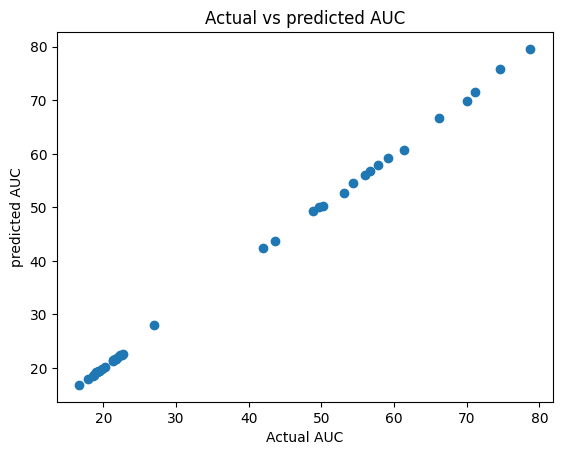

In [19]:
import matplotlib.pyplot as plt
plt.scatter(y_test, predictions)
plt.xlabel("Actual AUC")
plt.ylabel("predicted AUC")
plt.title("Actual vs predicted AUC")
plt.show()

  The plot shows there is a strong linear relationship. The model predicts well

#create a new patient with

- clearance = 6
- volume = 42
- genotype_Slow = 0, meaning Fast genotype.

 the model predicts the patient's AUC.

In [17]:
joblib.dump(model, 'model.pk1')
model = joblib.load('model.pk1')
new_pt = pd.DataFrame({
    "cl": [6],
    "v":[42],
    "genotype_Slow":[0]})
pred= model.predict(new_pt)
print(f"predicted AUC :{model.predict(new_pt)}")

predicted AUC :[49.1705305]


#Result:

MSE: 1.27 is low so the prediction error is small.

r2_score: is 0.99 close to one means model predicts well.

New patient prediction:

predicted AUC :49.17. model prediction is close to perfect.

Model is predicting AUC accuretly because clearance directly determines the AUC in the dataset. RandomForest learned the relationship very well.